# Arrhenius Rate Constants

This tutorial demonstrates how to use KiRATE's `Arrhenius` class to compute temperature-dependent rate constants for gas-phase chemical reactions. The Arrhenius formulation is the most fundamental expression in chemical kinetics, relating reaction rates to temperature through the activation energy barrier.

In [1]:
# --------------------------------------------------------
# External packages
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --------------------------------------------------------
# KiRATE modules
from KiRATE.kinetics import Arrhenius

## Theory

The modified Arrhenius equation describes the temperature dependence of reaction rate constants:

$$k(T) = A \cdot T^n \cdot \exp\left(-\frac{E_a}{RT}\right)$$

where:
- $k(T)$ = rate constant as a function of temperature
- $A$ = pre-exponential factor (frequency factor)
- $T$ = absolute temperature [K]
- $n$ = temperature exponent (dimensionless)
- $E_a$ = activation energy [cal/mol]
- $R$ = universal gas constant [cal/(mol·K)]

**Note:** When $n = 0$, this reduces to the standard Arrhenius equation.

---

## Creating Arrhenius Objects

KiRATE supports two methods for initializing Arrhenius rate constants:

### 1. From Python Dictionary

```python
reaction = Arrhenius(
    name="H2+O=H+OH",
    parameters={"A": 5.080e+04, "n": 2.670, "Ea": 6.292e+03}
)
```

### 2. From CHEMKIN Format String

The CHEMKIN format is the standard in combustion chemistry databases:

```
REACTION_NAME    A    n    Ea
```

Example:
```python
reaction = Arrhenius.from_chemkin("H2+O=H+OH  5.080e+04 2.670 6.292e+03")
```

**Validation:** KiRATE automatically validates parameters to ensure physical consistency.

In [2]:
# --------------------------------------------------------
# Construction from a Python dictionary
reaction = Arrhenius(name="H2+O=H+OH", parameters={"A": 5.080e04, "n": 2.670, "Ea": 6.292e03})

# --------------------------------------------------------
# Alternative: Construction from CHEMKIN-formatted string
# reaction = Arrhenius.from_chemkin("H2+O=H+OH  5.080e+04 2.670 6.292e+03")

# --------------------------------------------------------
# Object inspection
print("Detailed representation:")
print(repr(reaction))
print("\nCHEMKIN format:")
print(str(reaction))

Detailed representation:
Arrhenius(
 name = H2+O=H+OH
 A    = 5.08000e+04
 n    = 2.67000e+00
 Ea   = 6.29200e+03
)

CHEMKIN format:
H2+O=H+OH		5.08000E+04 2.67000E+00 6.29200E+03


## Computing Rate Constants

The `rate_constant()` method evaluates $k(T)$ over any temperature range. KiRATE uses JAX for automatic vectorization, enabling efficient computation across arrays of temperatures.

**Key Features:**
- **Vectorized evaluation:** Pass scalar or array temperatures
- **JIT compilation:** First call compiles, subsequent calls are fast
- **Automatic differentiation:** Built-in gradients for optimization

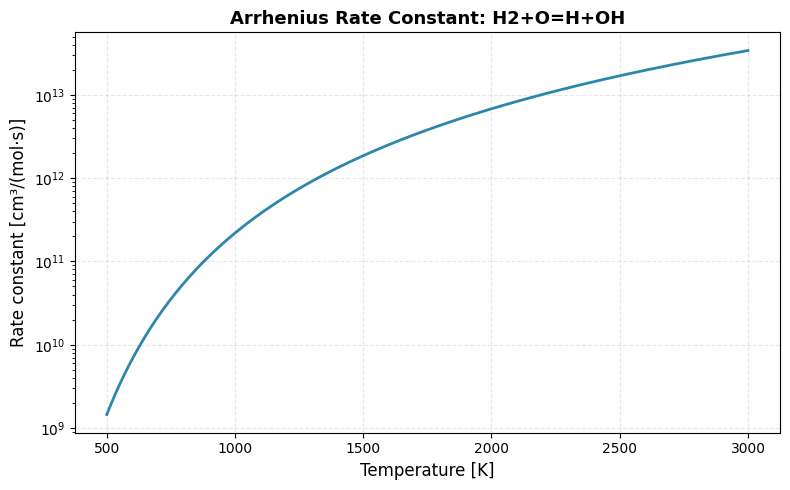


Rate constant at 1000 K: 2.192e+11 cm³/(mol·s)


In [3]:
# --------------------------------------------------------
# Define temperature range (500 K to 3000 K)
T_range = jnp.linspace(500, 3000, 300)

# --------------------------------------------------------
# Compute rate constants - fully vectorized!
k = reaction.rate_constant(T_range)

# --------------------------------------------------------
# Visualize the Arrhenius behavior
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(T_range, k, linewidth=2, color="#2E86AB")
ax.set_xlabel("Temperature [K]", fontsize=12)
ax.set_ylabel("Rate constant [cm³/(mol·s)]", fontsize=12)
ax.set_title(f"Arrhenius Rate Constant: {reaction.name}", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

print(f"\nRate constant at 1000 K: {reaction.rate_constant(1000.0):.3e} cm³/(mol·s)")

## Advanced Features

### Property Access

The `Arrhenius` class provides convenient property accessors for all parameters:

| Property | Description | Units |
|----------|-------------|-------|
| `name` | Reaction identifier | - |
| `A` | Pre-exponential factor | varies |
| `lnA` | Natural log of A | - |
| `n` | Temperature exponent | - |
| `Ea` | Activation energy | cal/mol |
| `EaR` | Ea/R (activation temperature) | K |

### Converting to Standard Arrhenius

For cases where $n \neq 0$, you can convert to the standard form ($n = 0$) at a reference temperature using `convert_to_standard_arrhenius()`.

STORED PARAMETERS
Reaction name:                    H2+O=H+OH
Pre-exponential factor A:         5.080e+04
ln(A):                            10.835652
Temperature exponent n:           2.670
Activation energy Ea:             6.292e+03 cal/mol
Activation temperature Ea/R:      3.166e+03 K
  New A = 1.039E+14, n = 0.000E+00, Ea = 1.106E+04


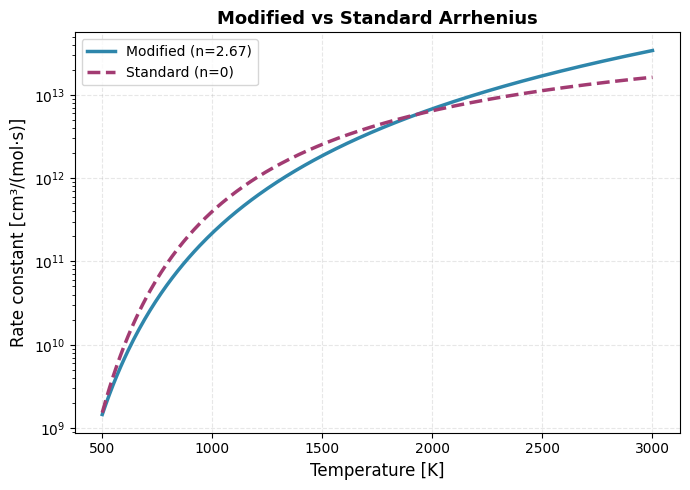

In [4]:
# --------------------------------------------------------
# Access stored parameters via properties
print("=" * 60)
print("STORED PARAMETERS")
print("=" * 60)
print(f"Reaction name:                    {reaction.name}")
print(f"Pre-exponential factor A:         {reaction.A:.3e}")
print(f"ln(A):                            {reaction.lnA:.6f}")
print(f"Temperature exponent n:           {reaction.n:.3f}")
print(f"Activation energy Ea:             {reaction.Ea:.3e} cal/mol")
print(f"Activation temperature Ea/R:      {reaction.EaR:.3e} K")
print("=" * 60)

# --------------------------------------------------------
# Convert modified Arrhenius (n ≠ 0) to standard form (n = 0)
standard_arrh = reaction.convert_to_standard_arrhenius()
print(f"  New A = {standard_arrh.A:.3E}, n = {standard_arrh.n:.3E}, Ea = {standard_arrh.Ea:.3E}")

# --------------------------------------------------------
# Compare modified vs standard Arrhenius
k_modified = reaction.rate_constant(T_range)
k_standard = standard_arrh.rate_constant(T_range)

fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))

# Plot 1: Both rate constants
ax1.semilogy(T_range, k_modified, linewidth=2.5, label=f"Modified (n={reaction.n:.2f})", color="#2E86AB")
ax1.semilogy(T_range, k_standard, linewidth=2.5, linestyle="--", label="Standard (n=0)", color="#A23B72")
ax1.set_xlabel("Temperature [K]", fontsize=12)
ax1.set_ylabel("Rate constant [cm³/(mol·s)]", fontsize=12)
ax1.set_title("Modified vs Standard Arrhenius", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

## Logarithmic Rate Constants

For numerical stability and optimization tasks, KiRATE provides `log_rate_constant()` which computes $\ln(k(T))$ directly:

$$\ln(k(T)) = \ln(A) + n \ln(T) - \frac{E_a}{RT}$$

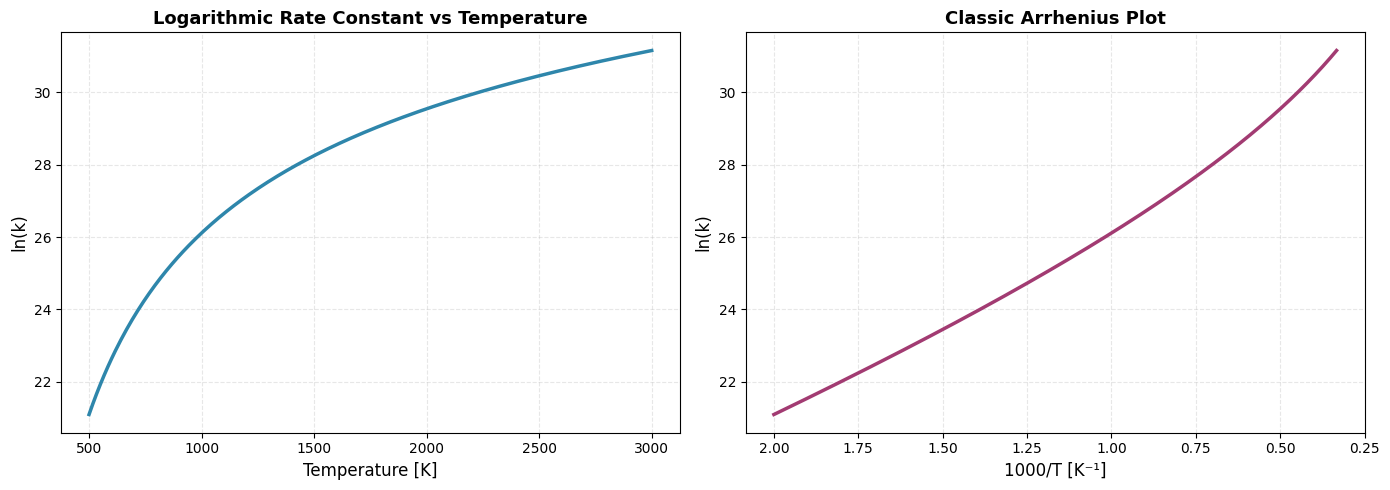

In [5]:
# --------------------------------------------------------
# Compute logarithmic rate constant
ln_k = reaction.log_rate_constant(T_range)

# --------------------------------------------------------
# Create classic Arrhenius plot: ln(k) vs 1/T
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ln(k) vs T
ax1.plot(T_range, ln_k, linewidth=2.5, color="#2E86AB")
ax1.set_xlabel("Temperature [K]", fontsize=12)
ax1.set_ylabel("ln(k)", fontsize=12)
ax1.set_title("Logarithmic Rate Constant vs Temperature", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3, linestyle="--")

# Plot 2: Classic Arrhenius plot (ln(k) vs 1/T)
inv_T = 1000.0 / T_range  # Convert to 1000/T for better visualization
ax2.plot(inv_T, ln_k, linewidth=2.5, color="#A23B72")
ax2.set_xlabel("1000/T [K⁻¹]", fontsize=12)
ax2.set_ylabel("ln(k)", fontsize=12)
ax2.set_title("Classic Arrhenius Plot", fontsize=13, fontweight="bold")
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.invert_xaxis()  # Higher T on the left

plt.tight_layout()
plt.show()

## Uncertainty Quantification

Chemical kinetics often involves significant uncertainties in rate parameters. KiRATE provides two methods for handling uncertainties:

### 1. Direct Rate Constant Bounds

The `rate_constant_bounds()` method applies an uncertainty factor directly to $k(T)$:

$$k_{lower}(T) = \frac{k(T)}{10^f}, \quad k_{upper}(T) = k(T) \times 10^f$$

where $f$ is the uncertainty factor. For example, $f=2$ means the rate constant can vary by a factor of 100 (10²).

### 2. Parameter Bounds

The `parameter_bounds()` method provides bounds on the Arrhenius parameters themselves for use in optimization or Monte Carlo sampling:
- **Correlated method**: Accounts for compensation effects between parameters
- **Independent method**: Treats parameter variations independently

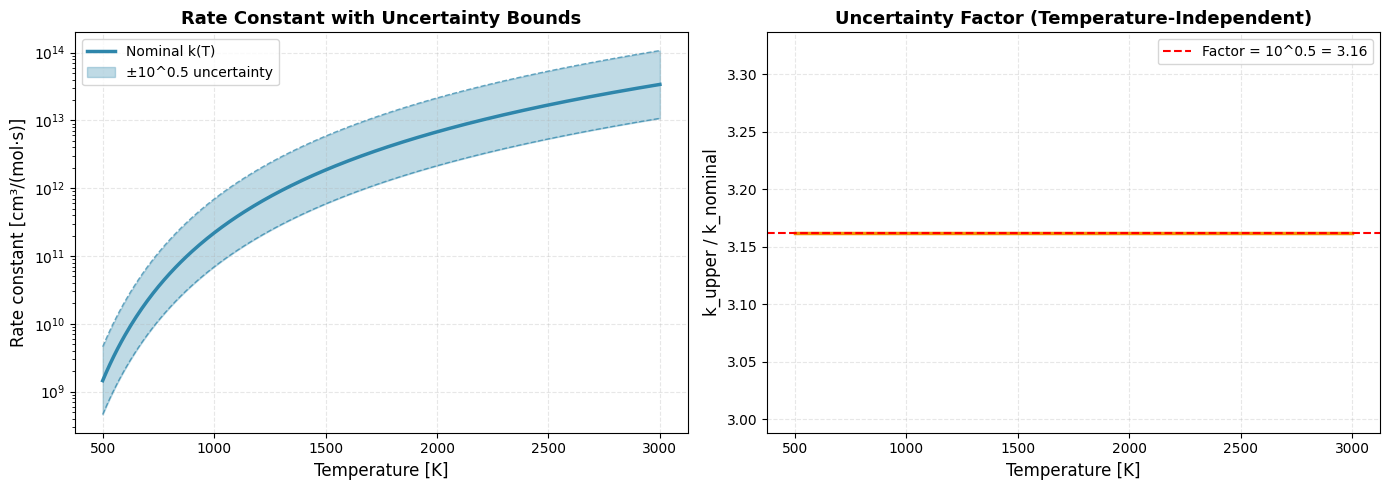

Uncertainty factor: 10^0.5 = 3.16x
At 1000 K:
  k_nominal = 2.192e+11 cm³/(mol·s)
  k_lower   = 6.999e+10 cm³/(mol·s)
  k_upper   = 6.999e+11 cm³/(mol·s)


In [6]:
# --------------------------------------------------------
# Define uncertainty factor (f=0.5 means factor of 10^0.5 ≈ 3.16)
uncertainty_factor = 0.5

# --------------------------------------------------------
# Compute rate constant bounds
k_nominal = reaction.rate_constant(T_range)
k_lower, k_upper = reaction.rate_constant_bounds(T_range, uncertainty_factor)

# --------------------------------------------------------
# Visualize uncertainty bounds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Rate constant with uncertainty bands
ax1.semilogy(T_range, k_nominal, linewidth=2.5, label="Nominal k(T)", color="#2E86AB")
ax1.fill_between(T_range, k_lower, k_upper, alpha=0.3, color="#2E86AB", label=f"±10^{uncertainty_factor} uncertainty")
ax1.semilogy(T_range, k_lower, linewidth=1, linestyle="--", color="#2E86AB", alpha=0.7)
ax1.semilogy(T_range, k_upper, linewidth=1, linestyle="--", color="#2E86AB", alpha=0.7)
ax1.set_xlabel("Temperature [K]", fontsize=12)
ax1.set_ylabel("Rate constant [cm³/(mol·s)]", fontsize=12)
ax1.set_title("Rate Constant with Uncertainty Bounds", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle="--")

# Plot 2: Uncertainty factor vs temperature
uncertainty_ratio = k_upper / k_nominal
ax2.plot(T_range, uncertainty_ratio, linewidth=2.5, color="#F18F01")
ax2.axhline(
    10**uncertainty_factor,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Factor = 10^{uncertainty_factor} = {10**uncertainty_factor:.2f}",
)
ax2.set_xlabel("Temperature [K]", fontsize=12)
ax2.set_ylabel("k_upper / k_nominal", fontsize=12)
ax2.set_title("Uncertainty Factor (Temperature-Independent)", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

print(f"Uncertainty factor: 10^{uncertainty_factor} = {10**uncertainty_factor:.2f}x")
print(f"At 1000 K:")
print(f"  k_nominal = {reaction.rate_constant(1000.0):.3e} cm³/(mol·s)")
print(f"  k_lower   = {k_lower[jnp.argmin(jnp.abs(T_range - 1000))]:.3e} cm³/(mol·s)")
print(f"  k_upper   = {k_upper[jnp.argmin(jnp.abs(T_range - 1000))]:.3e} cm³/(mol·s)")

PARAMETER BOUNDS FOR OPTIMIZATION/SAMPLING
Uncertainty factor: 10^0.5 = 3.16x

CORRELATED METHOD (accounting for compensation effects):
  ln(A):  [9.6844, 11.9869]
  n:      [-1.2393, 10.3961]
  Ea/R:   [-7098.6, 4605.4] K

INDEPENDENT METHOD (independent parameter variations):
  ln(A):  [9.6844, 11.9869]
  n:      [2.5229, 2.8171]
  Ea/R:   [2590.6, 3741.9] K


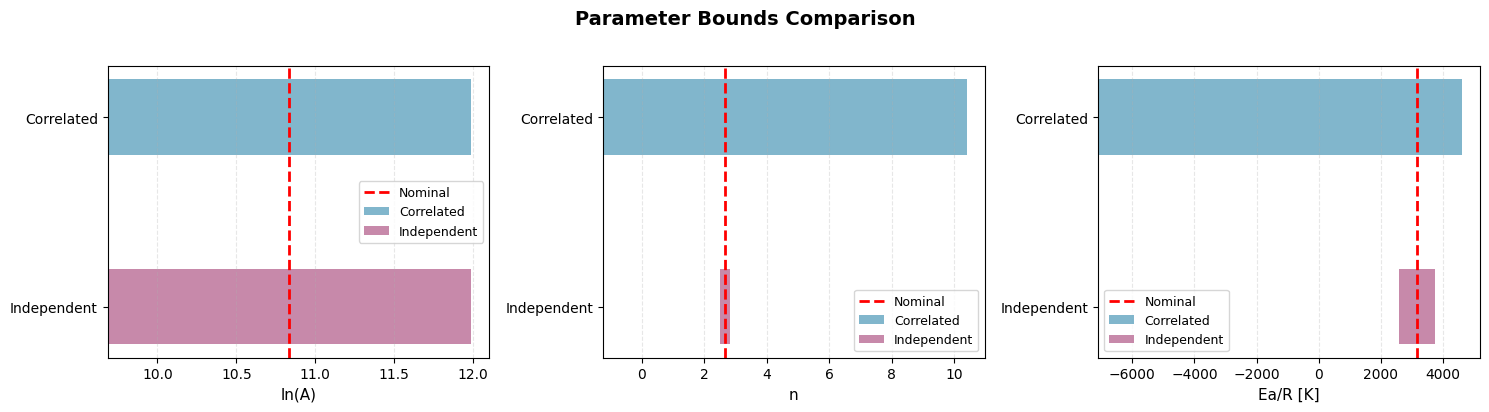

In [7]:
# --------------------------------------------------------
# Get parameter bounds using both methods
bounds_corr = reaction.parameter_bounds(uncertainty_factor=0.5, method="correlated", T_low=500.0, T_high=2500.0)

bounds_indep = reaction.parameter_bounds(uncertainty_factor=0.5, method="independent", T_low=500.0, T_high=2500.0)

# --------------------------------------------------------
# Display parameter bounds
print("=" * 70)
print("PARAMETER BOUNDS FOR OPTIMIZATION/SAMPLING")
print("=" * 70)
print(f"Uncertainty factor: 10^{uncertainty_factor} = {10**uncertainty_factor:.2f}x\n")

print("CORRELATED METHOD (accounting for compensation effects):")
print(f"  ln(A):  [{float(bounds_corr['lnA'][0]):.4f}, {float(bounds_corr['lnA'][1]):.4f}]")
print(f"  n:      [{float(bounds_corr['n'][0]):.4f}, {float(bounds_corr['n'][1]):.4f}]")
print(f"  Ea/R:   [{float(bounds_corr['EaR'][0]):.1f}, {float(bounds_corr['EaR'][1]):.1f}] K\n")

print("INDEPENDENT METHOD (independent parameter variations):")
print(f"  ln(A):  [{float(bounds_indep['lnA'][0]):.4f}, {float(bounds_indep['lnA'][1]):.4f}]")
print(f"  n:      [{float(bounds_indep['n'][0]):.4f}, {float(bounds_indep['n'][1]):.4f}]")
print(f"  Ea/R:   [{float(bounds_indep['EaR'][0]):.1f}, {float(bounds_indep['EaR'][1]):.1f}] K")
print("=" * 70)

# --------------------------------------------------------
# Visualize parameter space bounds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

params_nominal = {"lnA": float(reaction.lnA), "n": float(reaction.n), "EaR": float(reaction.EaR)}
param_names = ["lnA", "n", "EaR"]
param_labels = ["ln(A)", "n", "Ea/R [K]"]

for i, (param, label) in enumerate(zip(param_names, param_labels)):
    ax = axes[i]

    # Correlated bounds
    corr_range = [float(bounds_corr[param][0]), float(bounds_corr[param][1])]
    ax.barh(
        1, corr_range[1] - corr_range[0], left=corr_range[0], height=0.4, color="#2E86AB", alpha=0.6, label="Correlated"
    )

    # Independent bounds
    indep_range = [float(bounds_indep[param][0]), float(bounds_indep[param][1])]
    ax.barh(
        0,
        indep_range[1] - indep_range[0],
        left=indep_range[0],
        height=0.4,
        color="#A23B72",
        alpha=0.6,
        label="Independent",
    )

    # Nominal value
    ax.axvline(params_nominal[param], color="red", linewidth=2, linestyle="--", label="Nominal")

    ax.set_xlabel(label, fontsize=11)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Independent", "Correlated"])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="x", linestyle="--")

plt.suptitle("Parameter Bounds Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()